# Example simulation LINTUL

Author: Herman Berghuijs

## 1. Introduction

The aim of this notebook is to show how LINTUL can be run under potential, water-limited, and water-and-nitrogen limited growth conditions. In this example, the growth of spring wheat in Wageningen (the Netherlands) in 1987 is simulated.


## 2. Collect model input

In [7]:
from pathlib import Path

cwd = Path.cwd()
input_dir = cwd / "input"
agro_dir = input_dir / "agro"
agro_fp = agro_dir / "agro.yaml"
crop_dir = input_dir / "crop"
crop_fp = crop_dir / "springwheat.yaml"
modelconf_dir = input_dir / "modelconf"
modelconf_pp_fp = modelconf_dir / "Lintul_original_PP.conf"
modelconf_wnlp_fp = modelconf_dir / "Lintul_original_WNLP.conf"
modelconf_wlp_fp = modelconf_dir / "Lintul_original_WLP.conf"
site_dir = input_dir / "site"
site_fp = site_dir / "site.yaml"
soil_dir = input_dir / "soil"
soil_fp = soil_dir / "soil.yaml"
weather_dir = input_dir / "weather"
weather_fn= weather_dir / "NLD1"

All input files, except for the weather files, are stored in a YAML format. Reading the content of these YAML files into a dictionary requires the yaml package, which is imported below.

In [8]:
import yaml

Next, the AgroManagement, crop, site, soil input YAML files are opened, read, and stored in dictionaries:

In [9]:
with open(crop_fp) as f:
    cropd = yaml.safe_load(f.read())
with open(agro_fp) as f:
    agrod = yaml.safe_load(f.read())
with open(soil_fp) as f:
    soild = yaml.safe_load(f.read())
with open(site_fp) as f:
    sited = yaml.safe_load(f.read())

The daily weather data and the weather station information are stored in CABO format. Reading this type of file requires the CABOWeatherDataProvider class from PCSE. Below, the daily weather data are read and stored in a CABOWeatherDataProvider object:

In [10]:
from pcse.input import CABOWeatherDataProvider
wdp = CABOWeatherDataProvider(fname=weather_fn, fpath=weather_dir)

All input files that are required to run a simulation are now loaded in a format that PCSE can read and use to run LINTUL Cassava NPK simulations. The crop, site, and soil data are combined in a ParameterProvider object, which requires the ParameterProvider class from PCSE:

In [11]:
from pcse.base import ParameterProvider
parameters = ParameterProvider(cropdata=cropd,
                               sitedata=sited,
                               soildata=soild)

## 3 Set model configuration

Next, the model configuration has to be loaded. The model configurations specifies, amongst others, which crop growth model is used for a simulation and which combination of soil water and soil nutrient model. In the first example simulation, we will run a simulation assuming potential growth using the model configuration Lintul_original_PP.conf. This file has the following content:

In [14]:
with open(modelconf_pp_fp) as f:
    model_conf_text = f.read()
print(model_conf_text)

from pathlib import Path

from lintul.lintul import LINTUL
from lintul.soilwrappers import Lintul_original_PP_SoilWrapper
from pcse.agromanager import AgroManager

SOIL = Lintul_original_PP_SoilWrapper
CROP = LINTUL
AGROMANAGEMENT = AgroManager
OUTPUT_VARS = ["DVS", "LAI", "WLVG", "WRT", "WSO", "WST", "NNI", "ANLV", "ANRT", "ANSO", "ANST", "WA"]
OUTPUT_INTERVAL = "daily"
OUTPUT_INTERVAL_DAYS = 1
OUTPUT_WEEKDAY = 0
SUMMARY_OUTPUT_VARS = []
TERMINAL_OUTPUT_VARS = []



The file contains a line "CROP = LINTUL". This indicates that the code of the crop model that is stored in an instance of the class LINTUL.

The line SOIL = Lintul_original_PP_SoilWrapper indicates that the combination of the soil water module and the soil nutrient module is stored in an instance of the class Lintul_Cassava_original_PP_SoilWrapper. The "PP" indicates that potential production is assumed. In the soil water module for potential growth, it is assumed that the amount of soil moisture in the rooted zone is always at field capacity. In the soil nitrogen module for potential growth, it is assumed that there is a large amount of nitrogen (100 g N m$^{^2}$) available every day to prevent any N stress during the simulation.

Using this configuration file to build a crop-soil model require the Engine class from PCSE.

In [15]:
from pcse.engine import Engine

Building the crop-soil model also requires access to the package lintul_cassava in the parent directory of the directory where this Notebook is stored:

In [16]:
import sys
sys.path.append(str(cwd.parent))

Now, the LINTUL model for potential growth that is described in the configuration file can be built and initialized:

In [17]:
lintul_pp = Engine(parameters, wdp, agrod, config=modelconf_pp_fp)

The resulting model is run from the start date until the end date.

In [19]:
lintul_pp.run_till_terminate()

And the model output is collected, stored in a dataframe. Making a dataframe requires the pandas Python package pandas:

In [20]:
import pandas as pd
output_pp = lintul_pp.get_output()
df_out_pp = pd.DataFrame(output_pp)

The model output is then stored in an Excel file for which we have to define an output path:

In [24]:
output_dir = cwd / "output"
output_pp_fp = output_dir / "output_pp.xlsx"
df_out_pp.to_excel(output_pp_fp, index = False)

The directory .../example/input/modelconf also contains model configuration files to run simulations for water-limited production (Lintul_original_WLP.conf) and water-and-nitrogen limited production (Lintul_original_WNLP.conf). The configuration file for water-limited growth contains the following text:

In [23]:
with open(modelconf_wlp_fp) as f:
    model_conf_wlp_text = f.read()
print(model_conf_wlp_text)

from pathlib import Path

from lintul.lintul import LINTUL
from lintul.soilwrappers import Lintul_original_WLP_SoilWrapper
from pcse.agromanager import AgroManager

SOIL = Lintul_original_WLP_SoilWrapper
CROP = LINTUL
AGROMANAGEMENT = AgroManager
OUTPUT_VARS = ["DVS", "LAI", "WLVG", "WRT", "WSO", "WST", "NNI", "ANLV", "ANRT", "ANSO", "ANST", "WA"]
OUTPUT_INTERVAL = "daily"
OUTPUT_INTERVAL_DAYS = 1
OUTPUT_WEEKDAY = 0
SUMMARY_OUTPUT_VARS = []
TERMINAL_OUTPUT_VARS = []



Unlike the model configuration for potential production, the LINTUL configuration file uses a Lintul_original_WLP_SoilWrapper. This instance of a SoilWrapper still assumes that there is a large amount of available nitrogen in the soil at all times, but it simulates the soil moisture content of the rooted soil dynamically. Therefore, water stress can occur if the soil moisture content of the rooted soil drops below a critical value. Again, the model is built, run, and the output is stored.

In [25]:
lintul_wlp = Engine(parameters, wdp, agrod, config=modelconf_wlp_fp)
lintul_wlp.run_till_terminate()
output_wlp = lintul_wlp.get_output()
df_out_wlp = pd.DataFrame(output_wlp)

output_wlp_fp = output_dir / "output_wlp.xlsx"
df_out_wlp.to_excel(output_wlp_fp, index = False)

Finally, a simulation will be done it which both water-and-nitrogen limited growth are considered. The text in the model configuration file looks like:

In [27]:
with open(modelconf_wnlp_fp) as f:
    model_conf_wnlp_text = f.read()
print(model_conf_wnlp_text)

from pathlib import Path

from lintul.lintul import LINTUL
from lintul.soilwrappers import Lintul_original_WNLP_SoilWrapper
from pcse.agromanager import AgroManager

SOIL = Lintul_original_WNLP_SoilWrapper
CROP = LINTUL
AGROMANAGEMENT = AgroManager
OUTPUT_VARS = ["DVS", "LAI", "WLVG", "WRT", "WSO", "WST", "NNI", "ANLV", "ANRT", "ANSO", "ANST", "WA"]
OUTPUT_INTERVAL = "daily"
OUTPUT_INTERVAL_DAYS = 1
OUTPUT_WEEKDAY = 0
SUMMARY_OUTPUT_VARS = []
TERMINAL_OUTPUT_VARS = []



Which shows that again another soilwrapper (Lintul_original_WNLP_SoilWrapper) is used, which simulates both the soil moisture content in the rooted soil and the amount of available N dynamically. Therefore,growth reductions due to both water and nitrogen deficiencies can occur in this simulation. The model is again built and run and the output is collected:

In [30]:
lintul_wnlp = Engine(parameters, wdp, agrod, config=modelconf_wnlp_fp)
lintul_wnlp.run_till_terminate()
output_wnlp = lintul_wnlp.get_output()
df_out_wnlp = pd.DataFrame(output_wnlp)

output_wnlp_fp = output_dir / "output_wlp.xlsx"
df_out_wnlp.to_excel(output_wnlp_fp, index = False)

And finally, a time plot is made for the growth of spring wheat under potential, water-limited, and water-and-nitrogen limited growth conditions in 1987:

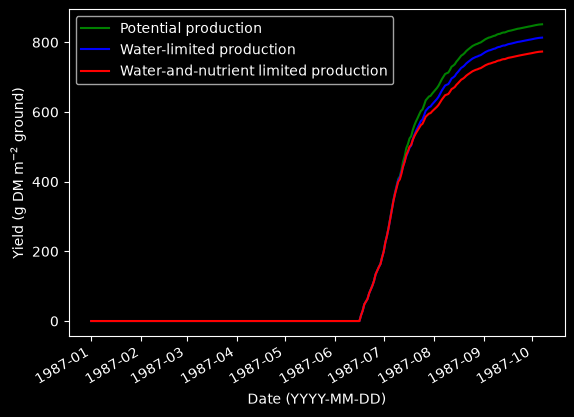

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_xlabel("Date (YYYY-MM-DD)")
ax.set_ylabel("Yield (g DM m$^{-2}$ ground)")
ax.plot(df_out_pp.day, df_out_pp.WSO, linestyle="-", color = 'g', label="Potential production")
ax.plot(df_out_wlp.day, df_out_wlp.WSO, linestyle="-", color = 'b', label="Water-limited production")
ax.plot(df_out_wnlp.day, df_out_wnlp.WSO, linestyle="-", color = 'r', label="Water-and-nutrient limited production")
ax.legend()
fig.autofmt_xdate()

The plot is saved to a JPEG file:

In [32]:
fig_fp = output_dir / "fig_WSO.jpeg"
fig.savefig(fig_fp, dpi = 900)